In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
print("all libraries imported")

all libraries imported


In [ ]:
df=pd.read_csv("train.csv")
plt.style.use("seaborn-v0_8")
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
display(df.head())
display(df.describe())
df.info()
missing=df.isna().sum()
missing_percentage= (missing / len(df)) * 100
missing_df=pd.DataFrame({
    "missing_counts":missing,
    "mising_percent":missing_percentage
    
}).sort_values("mising_percent",ascending=False)
print(missing_df.head(15))
print('-'*60)
num=df.select_dtypes(include=['int64','float64']).columns
cat=df.select_dtypes(include=['object']).columns
print("-"*60)
print('numeric:',len(num))
print("catagorical",len(cat))
print("-"*60)
mean=df['SalePrice'].mean()
median=df['SalePrice'].median()
print("mean of sale_price",mean)
print("median of sale_price",median)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:

num=df.select_dtypes(include=['int64','float64']).drop('Id', axis=1).columns
corr_pearson = df[num].corr()['SalePrice'].sort_values(ascending=False)
corr_spearman = df[num].corr(method='spearman')['SalePrice'].sort_values(ascending=False)
corr_compare = pd.DataFrame({
    "Pearson": corr_pearson,
    "Spearman": corr_spearman
})
corr_compare["Difference"] = abs(corr_compare["Spearman"] - corr_compare["Pearson"])
threshold = 0.05
def detect_relation(row):
    if abs(row["Pearson"]) < 0.2:
        return "Weak / No Clear Relation"
    elif row["Difference"] <= threshold:
        return "Likely Linear"
    else:
        return "Monotonic but Non-Linear"
corr_compare["Relation_Type"] = corr_compare.apply(detect_relation, axis=1)
corr_compare = corr_compare.drop("SalePrice")
corr_compare = corr_compare.sort_values(by="Pearson", ascending=False)
print(corr_compare)
linear_features = corr_compare[corr_compare["Relation_Type"] == "Likely Linear"].index.tolist()
print("Features with Likely Linear relation to SalePrice:")
print(linear_features)

                Pearson  Spearman  Difference             Relation_Type
OverallQual    0.790982  0.809829    0.018847             Likely Linear
GrLivArea      0.708624  0.731310    0.022685             Likely Linear
GarageCars     0.640409  0.690711    0.050302  Monotonic but Non-Linear
GarageArea     0.623431  0.649379    0.025947             Likely Linear
TotalBsmtSF    0.613581  0.602725    0.010855             Likely Linear
1stFlrSF       0.605852  0.575408    0.030444             Likely Linear
FullBath       0.560664  0.635957    0.075293  Monotonic but Non-Linear
TotRmsAbvGrd   0.533723  0.532586    0.001137             Likely Linear
YearBuilt      0.522897  0.652682    0.129784  Monotonic but Non-Linear
YearRemodAdd   0.507101  0.571159    0.064058  Monotonic but Non-Linear
GarageYrBlt    0.486362  0.593788    0.107427  Monotonic but Non-Linear
MasVnrArea     0.477493  0.421309    0.056184  Monotonic but Non-Linear
Fireplaces     0.466929  0.519247    0.052319  Monotonic but Non

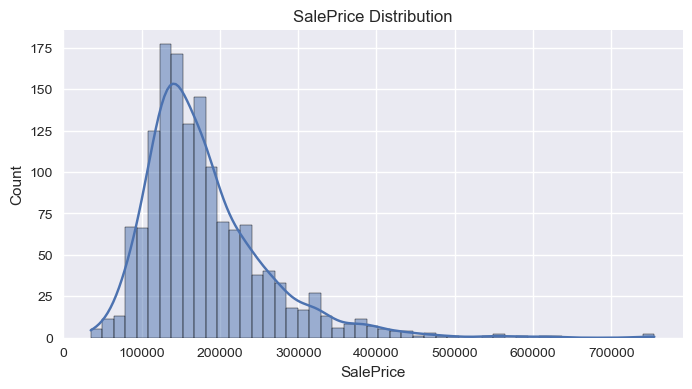

Skewness: 1.8828757597682129
Kurtosis: 6.536281860064529


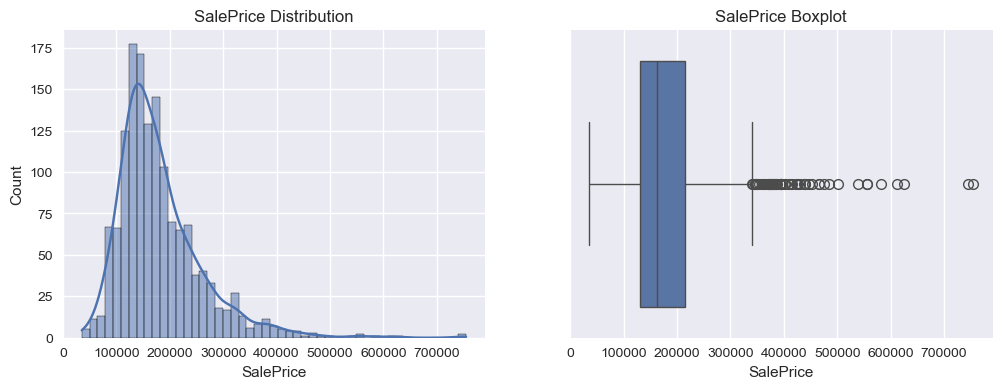

SalePrice Skewness: 1.8828757597682129
SalePrice Kurtosis: 6.536281860064529
--------------------------------------------------


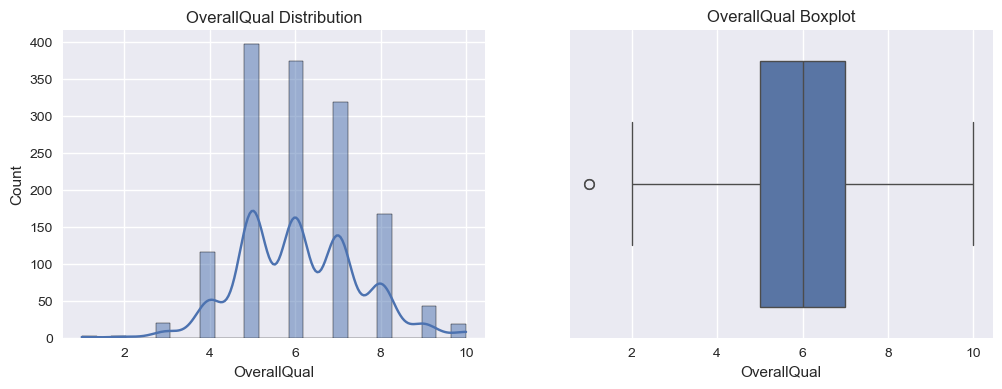

OverallQual Skewness: 0.2169439277628693
OverallQual Kurtosis: 0.09629277835615113
--------------------------------------------------


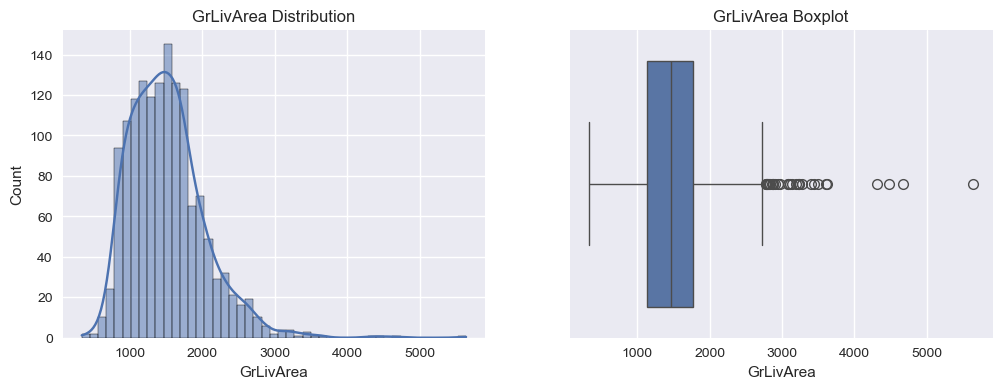

GrLivArea Skewness: 1.3665603560164552
GrLivArea Kurtosis: 4.895120580693174
--------------------------------------------------


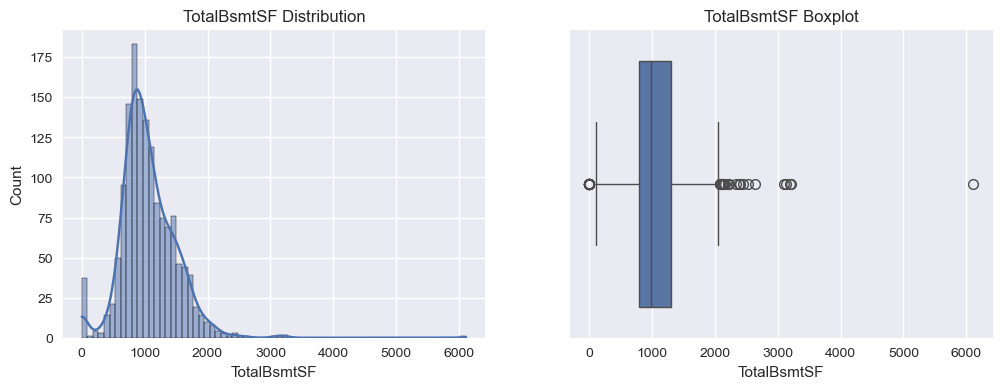

TotalBsmtSF Skewness: 1.5242545490627664
TotalBsmtSF Kurtosis: 13.250483281984796
--------------------------------------------------


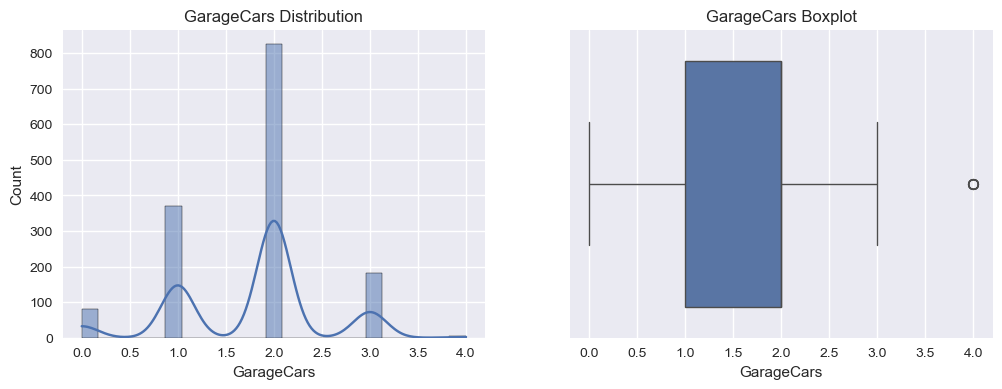

GarageCars Skewness: -0.3425489297486655
GarageCars Kurtosis: 0.22099776396532844
--------------------------------------------------


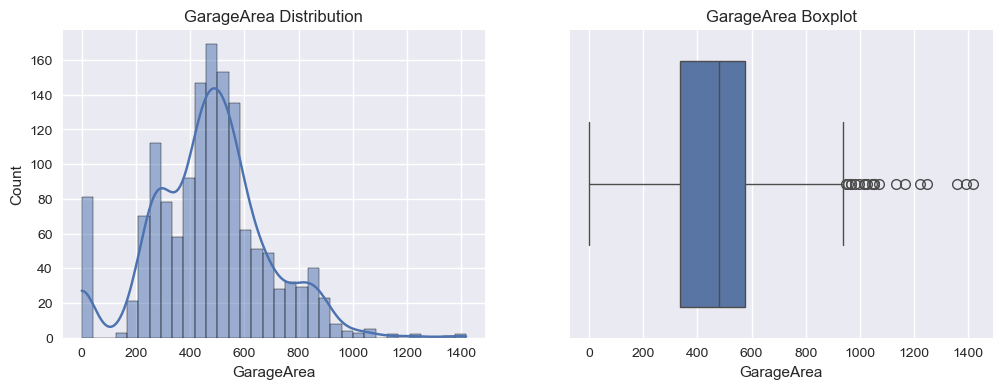

GarageArea Skewness: 0.17998090674623907
GarageArea Kurtosis: 0.9170672022708684
--------------------------------------------------


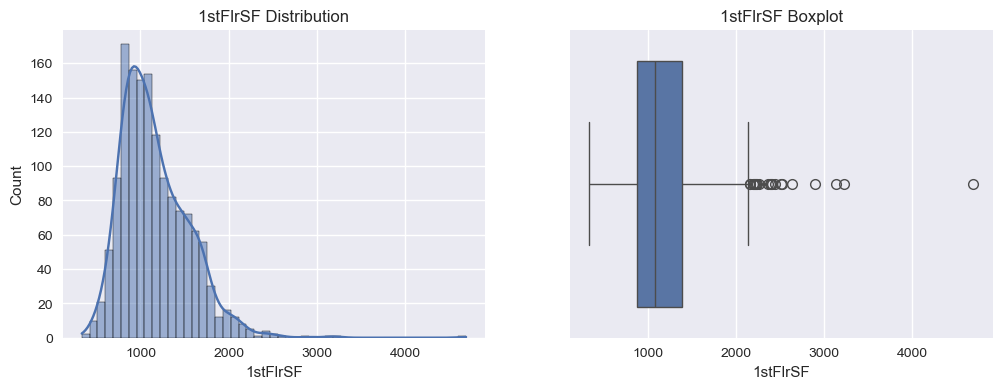

1stFlrSF Skewness: 1.3767566220336365
1stFlrSF Kurtosis: 5.74584148244079
--------------------------------------------------


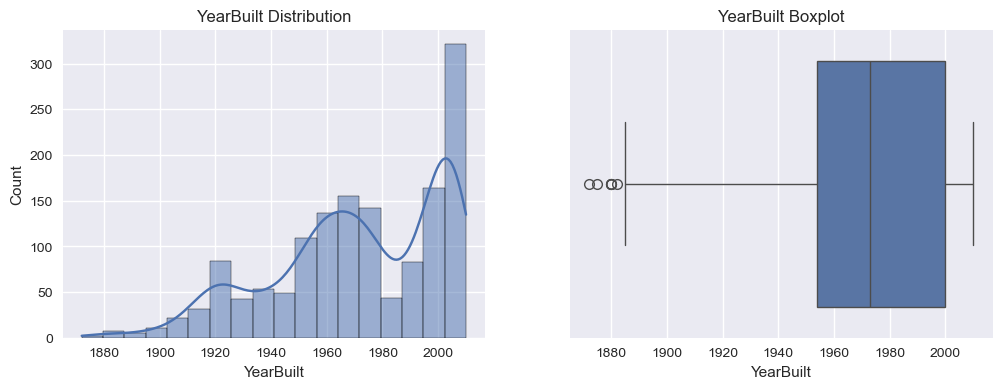

YearBuilt Skewness: -0.613461172488183
YearBuilt Kurtosis: -0.43955194159361977
--------------------------------------------------


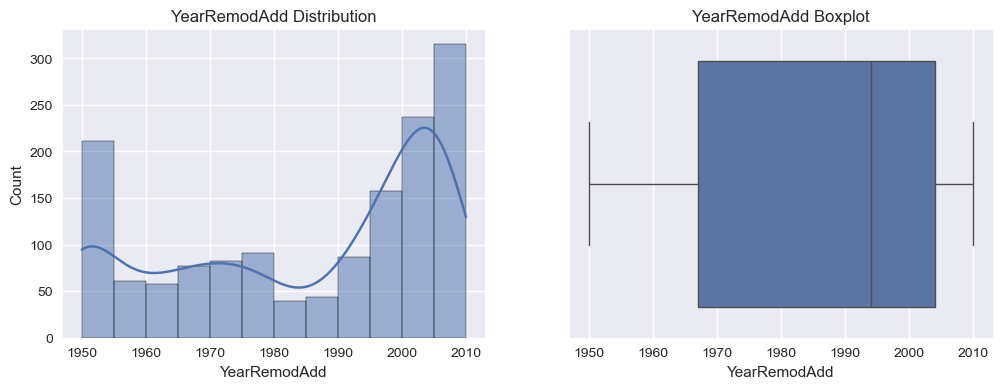

YearRemodAdd Skewness: -0.5035620027004709
YearRemodAdd Kurtosis: -1.2722451924732956
--------------------------------------------------


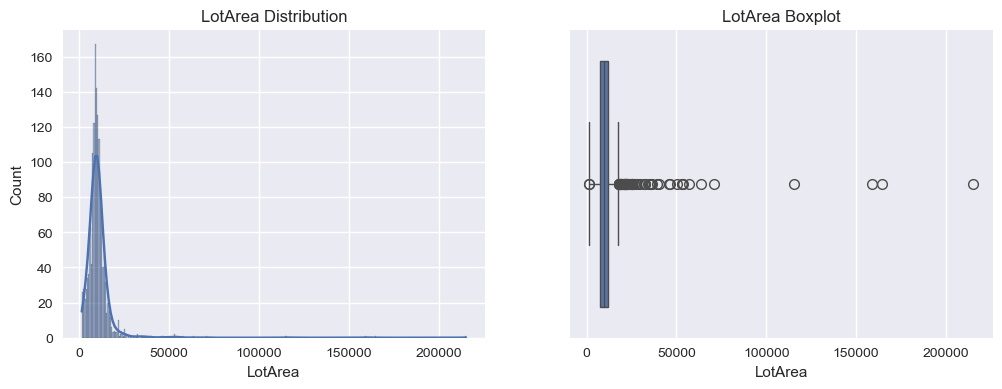

LotArea Skewness: 12.207687851233496
LotArea Kurtosis: 203.24327101886033
--------------------------------------------------


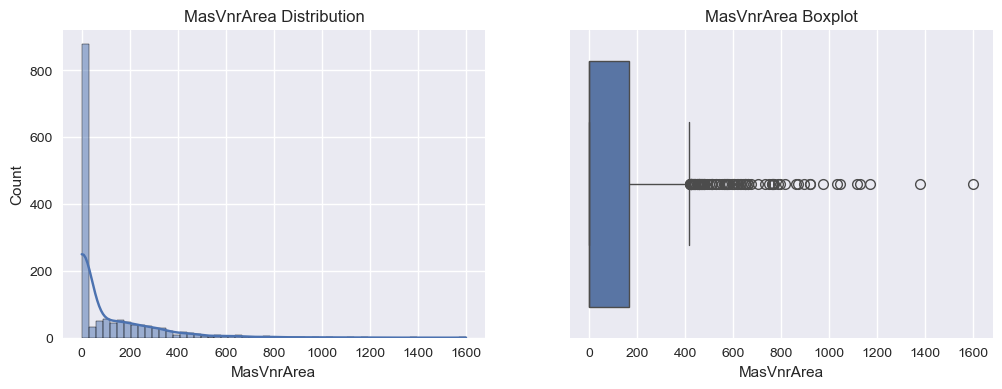

MasVnrArea Skewness: 2.669084210182863
MasVnrArea Kurtosis: 10.08241731736711
--------------------------------------------------


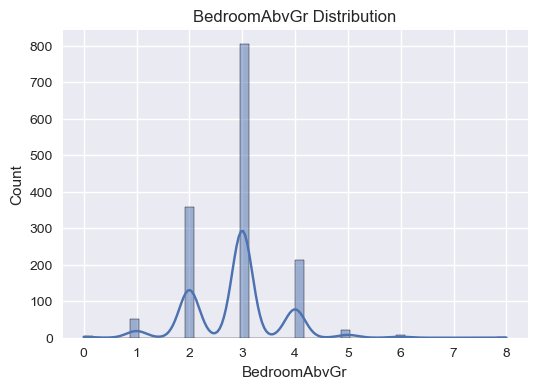

BedroomAbvGr Skewness: 0.21179009627507137
----------------------------------------


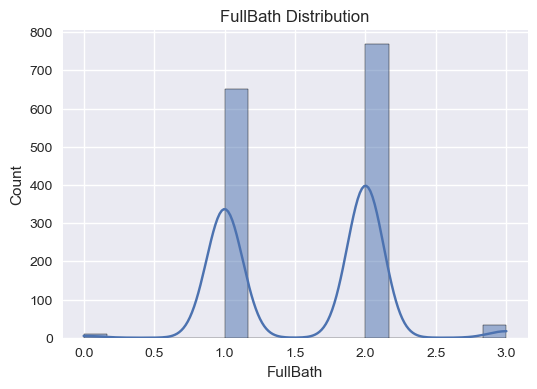

FullBath Skewness: 0.036561558402727165
----------------------------------------


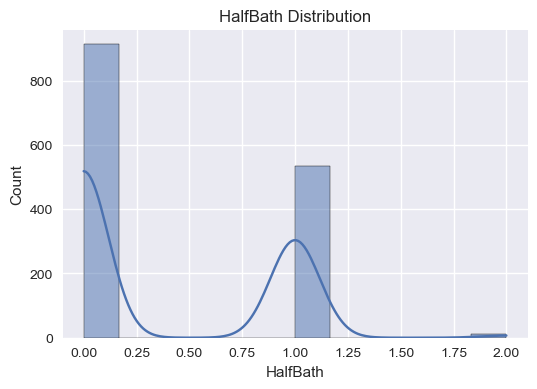

HalfBath Skewness: 0.675897448233722
----------------------------------------


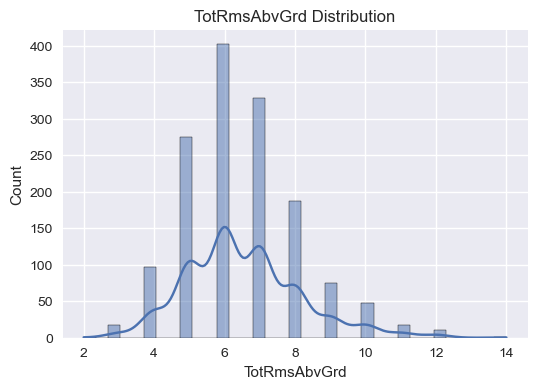

TotRmsAbvGrd Skewness: 0.6763408364355531
----------------------------------------


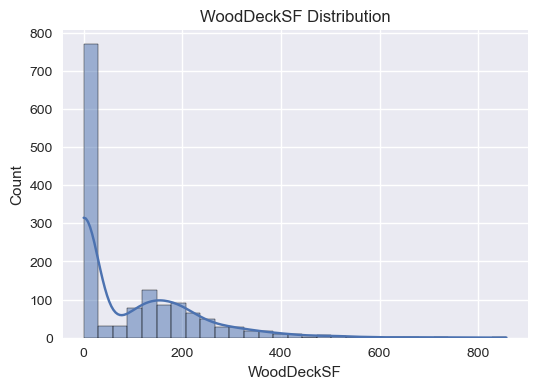

WoodDeckSF Skewness: 1.5413757571931312
----------------------------------------


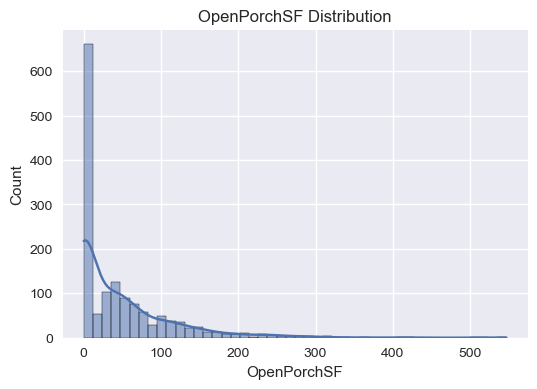

OpenPorchSF Skewness: 2.3643417403694404
----------------------------------------


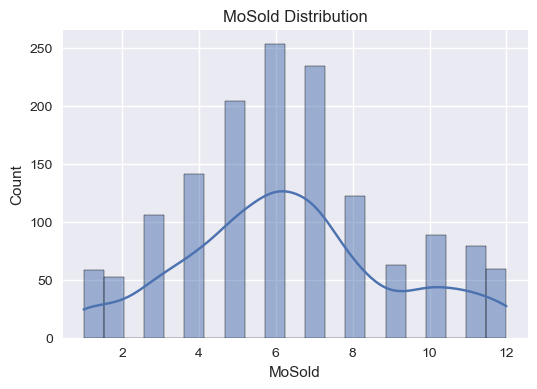

MoSold Skewness: 0.21205298505146022
----------------------------------------


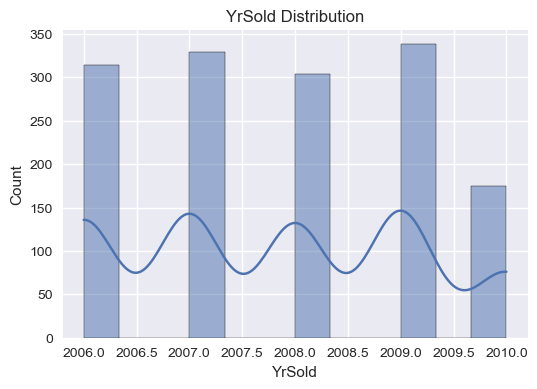

YrSold Skewness: 0.09626851386568028
----------------------------------------


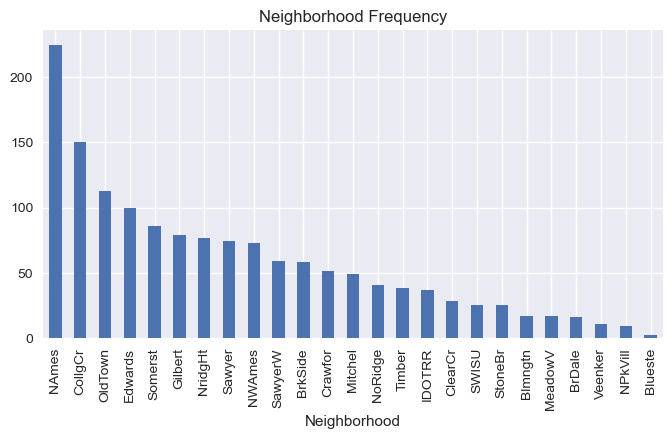

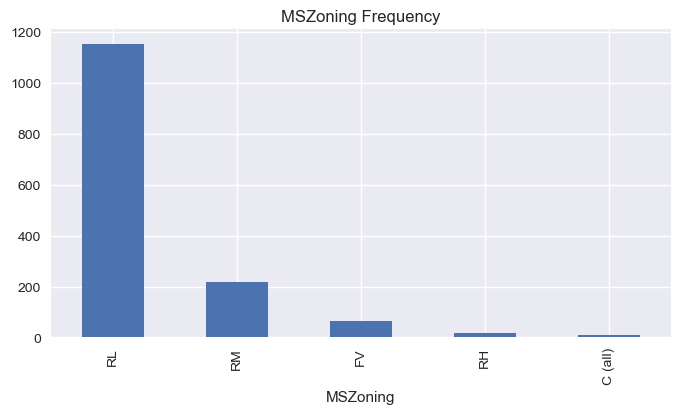

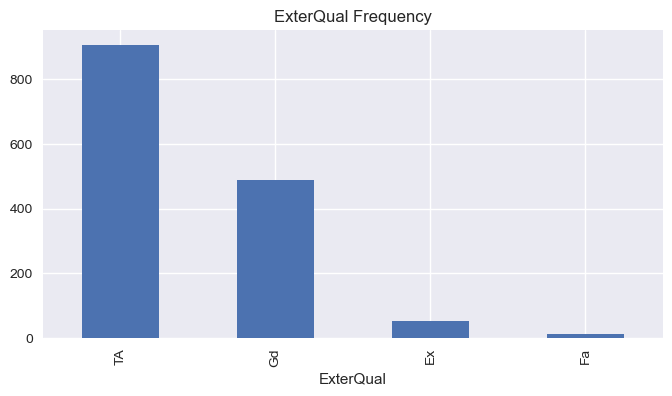

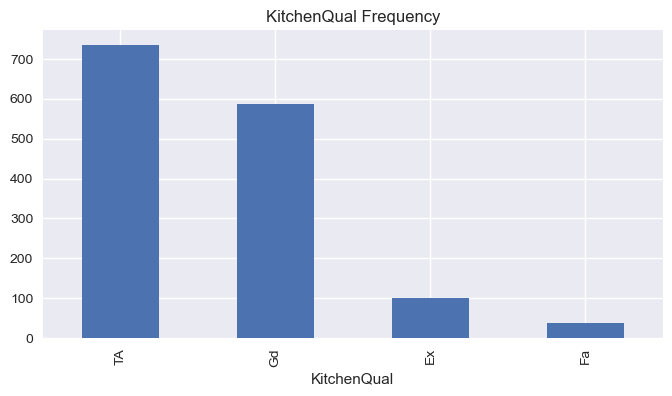

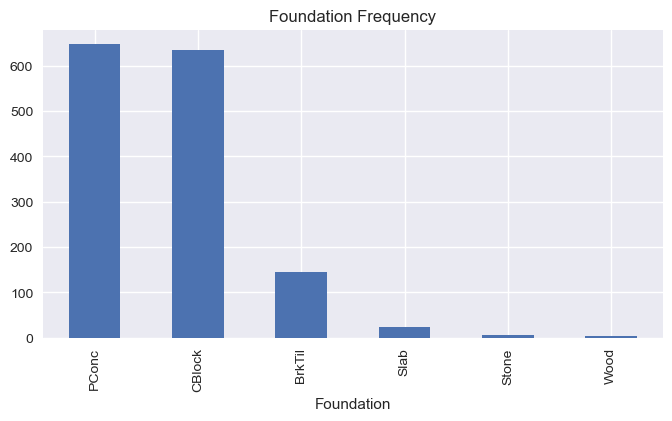

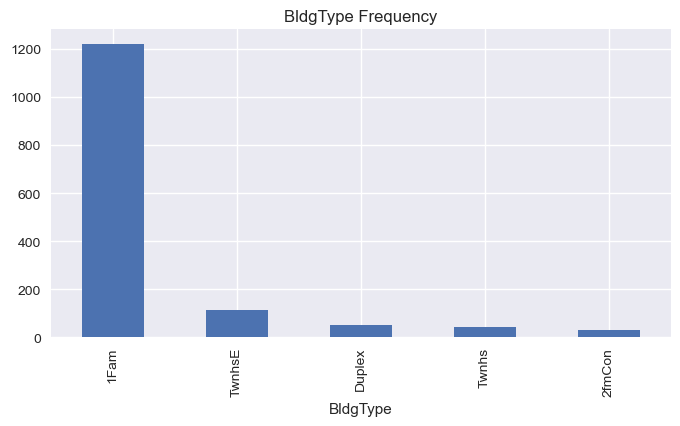

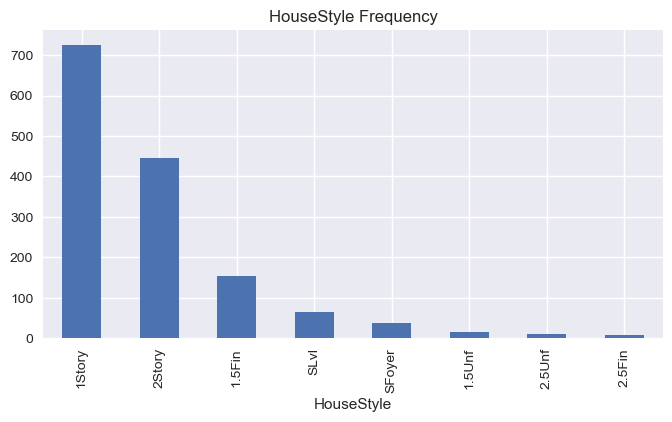

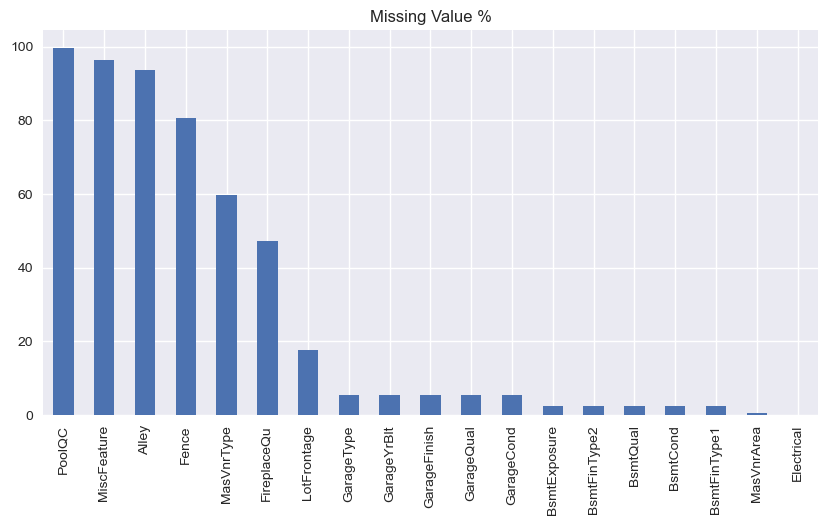

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()
print("Skewness:", df['SalePrice'].skew())
print("Kurtosis:", df['SalePrice'].kurt())
full_numeric = [
    'SalePrice','OverallQual','GrLivArea','TotalBsmtSF',
    'GarageCars','GarageArea','1stFlrSF',
    'YearBuilt','YearRemodAdd','LotArea','MasVnrArea'
]
for col in full_numeric:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    plt.show()
    print(f"{col} Skewness:", df[col].skew())
    print(f"{col} Kurtosis:", df[col].kurt())
    print("-"*50)
moderate_numeric = [
    'BedroomAbvGr','FullBath','HalfBath',
    'TotRmsAbvGrd','WoodDeckSF',
    'OpenPorchSF','MoSold','YrSold'
]
for col in moderate_numeric:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()
    print(f"{col} Skewness:", df[col].skew())
    print("-"*40)  
cat_full = [
    'Neighborhood','MSZoning','ExterQual',
    'KitchenQual','Foundation','BldgType','HouseStyle'
]
for col in cat_full:
    plt.figure(figsize=(8,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"{col} Frequency")
    plt.show()  
missing_percent = (df.isna().sum()/len(df))*100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
plt.figure(figsize=(10,5))
missing_percent.plot(kind='bar')
plt.title("Missing Value %")
plt.show()

In [5]:
drop_col=missing_percentage[missing_percentage>50].index
df.drop(columns=drop_col,inplace=True)
print("dropped columns",list(drop_col))
structural_cat = [
 'BsmtQual','BsmtCond','BsmtExposure',
 'BsmtFinType1','BsmtFinType2',
 'FireplaceQu',
 'GarageType','GarageFinish',
 'GarageQual','GarageCond'
]
structural_num = [
 'MasVnrArea','GarageYrBlt',
 'BsmtFinSF1','BsmtFinSF2',
 'BsmtUnfSF','TotalBsmtSF',
 'GarageArea','GarageCars'
]
for col in structural_cat:
    if col in df.columns:
        df[col] = df[col].fillna('None')
for col in structural_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)
num=df.select_dtypes(include=['int64','Float64']).columns
sekwness=df[num].skew().sort_values(ascending=False)
print(sekwness)
sekewed_cols=sekwness[(sekwness>1)|(sekwness<-1)].index
normal=sekwness[(sekwness<=1)&(sekwness>=-1)].index
median_imputer=SimpleImputer(strategy='median')
df[sekewed_cols]=median_imputer.fit_transform(df[sekewed_cols])
mean_imputer=SimpleImputer(strategy='mean')
df[normal]=mean_imputer.fit_transform(df[normal])
cat_cols = df.select_dtypes(include=['object']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])
print("Remaining Missing :", df.isnull().sum().sum())
print("-"*60)
corr_target = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print(corr_target)

dropped columns ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.677616
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
OverallCond       0.693067
TotRmsAbvGrd      0.676341
HalfBath          0.675897
Fireplaces        0.649565
BsmtFullBath      0.596067
OverallQual       0.216944
MoSold            0.212053
BedroomAbvGr      0.211790
GarageArea        0.179981
YrSold            0.096269
FullBath          0.036562
Id                0.000000
GarageCa

In [6]:
df["TotalSF"] = (
    df["TotalBsmtSF"]
    + df["1stFlrSF"]
    + df["2ndFlrSF"]
)
df["TotalBath"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)
drop_cols = ["Utilities","Street","Condition2","RoofMatl","Heating"]
df.drop(drop_cols, axis=1, inplace=True)
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)
df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["OverallScore"] = df["OverallQual"] * df["OverallCond"]
df["TotalHomeQuality"] = df["OverallQual"] * df["GrLivArea"]
df["TotalRooms"] = df["TotRmsAbvGrd"] + df["BedroomAbvGr"]
df["TotalOutdoorSF"] = (
    df["WoodDeckSF"]
    + df["OpenPorchSF"]
    + df["EnclosedPorch"]
    + df["3SsnPorch"]
    + df["ScreenPorch"]
)

df["AgeRemodRatio"] = df["HouseAge"] / (df["RemodAge"] + 1)
df["QualSF"] = df["OverallQual"] * df["TotalSF"]
drop_cols = [
  
    "1stFlrSF", "2ndFlrSF", "TotalBsmtSF", "OpenPorchSF",
    "EnclosedPorch","ScreenPorch",
    "FullBath", "HalfBath", "BsmtFullBath",
    "OverallQual", "OverallCond"
]

df.drop(columns=drop_cols, inplace=True)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
garage_drop_cols = ["GarageType", "GarageYrBlt", "GarageFinish", "GarageCars", "GarageCond"]
df.drop(columns=garage_drop_cols, inplace=True)
df.drop(columns=["GarageQual"], inplace=True)
multi_drop_cols = [
    "GarageArea",
    "TotRmsAbvGrd",    
]
df.drop(columns=multi_drop_cols, inplace=True)


In [7]:
num=df.select_dtypes(include=['int64','float64']).columns
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['SalePrice'] < lower) | (df['SalePrice'] > upper)]
print("Total Outliers (IQR) in sale price:", outliers.shape[0])
df['SalePrice'] = np.log1p(df['SalePrice'])
pt_yj = PowerTransformer(method='yeo-johnson')
df_yj = pt_yj.fit_transform(df[num])

Total Outliers (IQR) in sale price: 61


c:\Users\asims\anaconda3\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


In [8]:
# BsmtExposure
exp_map = {"No":0, "Mn":1, "Av":2, "Gd":3}
df["BsmtExposure"] = df["BsmtExposure"].map(exp_map)
# BsmtFinType
fin_map = {
    "Unf":0, "LwQ":1, "Rec":2,
    "BLQ":3, "ALQ":4, "GLQ":5
}
df["BsmtFinType1"] = df["BsmtFinType1"].map(fin_map)
df["BsmtFinType2"] = df["BsmtFinType2"].map(fin_map)
# Functional
func_map = {
    "Sev":0, "Maj2":1, "Maj1":2,
    "Mod":3, "Min2":4, "Min1":5, "Typ":6
}
df["Functional"] = df["Functional"].map(func_map)
# CentralAir binary
df["CentralAir"] = df["CentralAir"].map({"N":0, "Y":1})
qual_map = {
    "None":0,
    "Po":1,
    "Fa":2,
    "TA":3,
    "Gd":4,
    "Ex":5
}
qual_cols = [
    "ExterQual","ExterCond","BsmtQual",
    "BsmtCond","HeatingQC",
    "KitchenQual","FireplaceQu"
]
for col in qual_cols:
    df[col] = df[col].map(qual_map)
df["PavedDrive"] = df["PavedDrive"].map({
    "N":0,
    "P":1,
    "Y":2
})
low_card_cols = [
    "MSZoning","LotShape","LandContour",
    "LotConfig","LandSlope","BldgType",
    "HouseStyle","RoofStyle","Foundation",
    "SaleType","SaleCondition"
]

df = pd.get_dummies(
    df,
    columns=low_card_cols,
    drop_first=True
)
high_card_cols = [
    "Neighborhood",
    "Exterior1st",
    "Exterior2nd",
    "Condition1"
]

for col in high_card_cols:
    freq = df[col].value_counts() / len(df)
    df[col] = df[col].map(freq)
def rare_group(col, thresh=0.01):
    freq = df[col].value_counts(normalize=True)
    rare_labels = freq[freq < thresh].index
    df[col] = df[col].replace(rare_labels, "Rare")

rare_group("Neighborhood")
df = pd.get_dummies(
    df,
    columns=["Neighborhood", "Electrical"],
    drop_first=True 
)

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    median = df[col].median()
    df[col] = df[col].apply(lambda x: median if x < lower or x > upper else x)

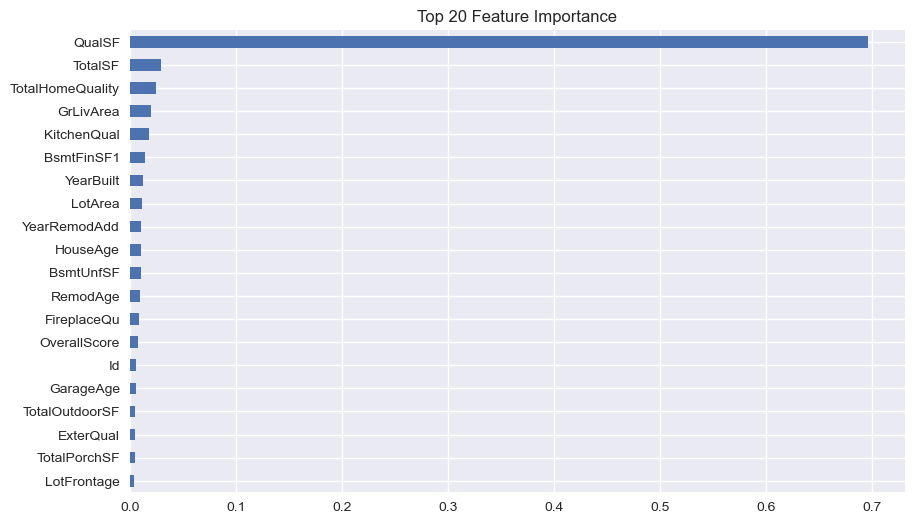

QualSF              0.695596
TotalSF             0.029658
TotalHomeQuality    0.024774
GrLivArea           0.020346
KitchenQual         0.018383
BsmtFinSF1          0.014486
YearBuilt           0.012336
LotArea             0.011290
YearRemodAdd        0.010930
HouseAge            0.010557
BsmtUnfSF           0.010339
RemodAge            0.009577
FireplaceQu         0.008531
OverallScore        0.007790
Id                  0.006305
GarageAge           0.005459
TotalOutdoorSF      0.005299
ExterQual           0.004781
TotalPorchSF        0.004735
LotFrontage         0.004424
dtype: float64
QualSF                              0.302431
Neighborhood_0.05273972602739726    0.110462
KitchenQual                         0.085201
MSZoning_RM                         0.045147
Neighborhood_0.0773972602739726     0.033943
TotalHomeQuality                    0.033374
TotalSF                             0.022862
CentralAir                          0.018218
ExterQual                           0.015980


In [9]:
X = df.drop(columns=['SalePrice'])   
y = df['SalePrice']   
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
import pandas as pd
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)
importance = importance.sort_values(ascending=False)
top_features = importance.head(35).index
X_train_filtered = X_train[top_features]
X_test_filtered  = X_test[top_features]
plt.figure(figsize=(10,6))
importance.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importance")
plt.gca().invert_yaxis()
plt.show()
top20_importance = importance.head(20)
print(top20_importance)
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)
print(xgb_importance.head(20))  


In [10]:

top_rf = importance  
top_xgb = xgb_importance  
threshold = 0.005
low_rf = top_rf[top_rf < threshold].index
low_xgb = top_xgb[top_xgb < threshold].index
low_features = list(set(low_rf).intersection(low_xgb))
print("Features to drop (low importance in both models):", low_features)
X_train_filtered = X_train.drop(columns=low_features)
X_test_filtered  = X_test.drop(columns=low_features)
print("Original number of features:", X_train.shape[1])
print("Number of features after filtering:", X_train_filtered.shape[1])


Features to drop (low importance in both models): ['BsmtHalfBath', 'Exterior1st', 'Neighborhood_0.04041095890410959', 'RoofStyle_Gable', 'SaleType_Con', 'HouseStyle_2.5Unf', 'SaleCondition_Alloca', 'HouseStyle_1.5Unf', 'Neighborhood_0.050684931506849315', 'RoofStyle_Shed', 'AgeRemodRatio', 'Electrical_FuseP', 'WoodDeckSF', 'PoolArea', 'MSZoning_FV', 'BedroomAbvGr', 'RoofStyle_Gambrel', 'Condition1', 'Neighborhood_0.026027397260273973', 'RoofStyle_Mansard', 'SaleCondition_Normal', 'SaleCondition_AdjLand', 'SaleType_Oth', 'RoofStyle_Hip', 'Electrical_Mix', 'SaleCondition_Partial', 'Neighborhood_0.0589041095890411', 'Neighborhood_0.03356164383561644', 'LotShape_IR2', 'SaleType_ConLw', 'Electrical_SBrkr', 'Neighborhood_0.1541095890410959', 'Neighborhood_0.10273972602739725', 'Neighborhood_0.025342465753424658', 'SaleType_ConLD', 'SaleType_ConLI', 'LandSlope_Sev', 'HouseStyle_SFoyer', 'LotConfig_Inside', 'BldgType_TwnhsE', 'LandContour_HLS', 'HouseStyle_1Story', 'Neighborhood_0.054109589041

In [11]:

features_to_keep = [
'LotFrontage','LotArea',
'BsmtFinSF1',
'GrLivArea','CentralAir',
'Fireplaces','FireplaceQu','PavedDrive',
'TotalBath','HouseAge','GarageAge',
'OverallScore',
'MSZoning_RL','MSZoning_RM',
'LotShape_Reg','LandContour_Low',
'BldgType_Twnhs','RoofStyle_Gable','SaleType_New'
]
X = df[features_to_keep].astype(float)
y = df["SalePrice"].astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=5,
    random_state=42
)
xgb.fit(X_train, y_train)
def evaluate_model(model, X_train, y_train, X_test, y_test, name="Model"):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    print(f"\n{name} Performance:")
    print("Train R²:", r2_score(y_train, y_pred_train))
    print("Test R²:", r2_score(y_test, y_pred_test))
    print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
    print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
    print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
evaluate_model(ridge, X_train, y_train, X_test, y_test, name="Ridge Regression")
evaluate_model(xgb, X_train, y_train, X_test, y_test, name="Regularized XGBoost")
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]
print("\nVariance Inflation Factor (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))


Ridge Regression Performance:
Train R²: 0.779769173273201
Test R²: 0.7797767026190771
Train RMSE: 0.16765586592679604
Test RMSE: 0.1765520592276824
Train MAE: 0.11664953877441128
Test MAE: 0.12146804600669363

Regularized XGBoost Performance:
Train R²: 0.8951122505966558
Test R²: 0.7855897305852362
Train RMSE: 0.11570232390143195
Test RMSE: 0.17420633663470042
Train MAE: 0.0820139249382768
Test MAE: 0.11646901639002834

Variance Inflation Factor (VIF):
            feature        VIF
0       LotFrontage  30.473762
8         TotalBath  28.056041
11     OverallScore  24.264395
3         GrLivArea  19.182511
1           LotArea  19.048115
7        PavedDrive  17.755836
4        CentralAir  17.450475
12      MSZoning_RL  14.573458
6       FireplaceQu   9.794229
5        Fireplaces   8.923461
9          HouseAge   8.036949
10        GarageAge   6.941645
17  RoofStyle_Gable   4.497113
13      MSZoning_RM   3.452235
14     LotShape_Reg   3.103746
2        BsmtFinSF1   2.541314
18     SaleType

In [12]:

features_to_keep = [
'LotFrontage','LotArea',
'BsmtFinSF1',
'GrLivArea','CentralAir',
'Fireplaces','FireplaceQu','PavedDrive',
'TotalBath','HouseAge','GarageAge',
'OverallScore',
'MSZoning_RL','MSZoning_RM',
'LotShape_Reg','LandContour_Low',
'BldgType_Twnhs','RoofStyle_Gable','SaleType_New'
]
X = df[features_to_keep].astype(float)
y = df["SalePrice"].astype(float)
pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('ridge', Ridge())
])
param_grid = {
    'ridge__alpha': np.logspace(-3, 3, 50)  # 0.001 → 1000
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X, y)
print("Best Alpha:", grid.best_params_)
print("Best Cross-Validated R²:", grid.best_score_)
best_model = grid.best_estimator_
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=kf,
    scoring='r2'
)
print("Fold-wise R²:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

coef_df = pd.DataFrame({
    'Feature': features_to_keep,
    'Coefficient': best_model.named_steps['ridge'].coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)
evaluate_model(best_model, X_train, y_train, X_test, y_test, name="Best Ridge CV")

Best Alpha: {'ridge__alpha': np.float64(33.9322177189533)}
Best Cross-Validated R²: 0.7712988922988963
Fold-wise R²: [0.77686654 0.75800795 0.7597043  0.79329035 0.76862532]
Mean CV R²: 0.7712988922988961
Std CV R²: 0.01290623767765409
            Feature  Coefficient
3         GrLivArea     0.127803
9          HouseAge    -0.082967
11     OverallScore     0.081368
2        BsmtFinSF1     0.055898
6       FireplaceQu     0.044220
10        GarageAge    -0.033184
13      MSZoning_RM    -0.032166
1           LotArea     0.029713
18     SaleType_New     0.023283
12      MSZoning_RL    -0.019838
16   BldgType_Twnhs    -0.017445
15  LandContour_Low     0.012859
8         TotalBath     0.011767
5        Fireplaces     0.008313
14     LotShape_Reg    -0.007567
17  RoofStyle_Gable    -0.006115
4        CentralAir     0.003961
7        PavedDrive     0.003332
0       LotFrontage     0.000278

Best Ridge CV Performance:
Train R²: 0.7792064354704865
Test R²: 0.7863684795755604
Train RMSE: 0.16786